# Minimiser le makespan d'un atelier de type job-shop avec PROC OPTMODEL


## Résumé

Une petite cellule de fabrication discrète doit faire passer quatre pièces — un **Support** (Bracket), une **Bride** (Flange), un **Carter** (Housing) et un **Arbre** (Shaft) — à travers une séquence fixe de trois opérations d'usinage chacune, en partageant quatre machines à capacité unitaire (**Scie** / Saw, **Fraiseuse** / Mill, **Perceuse** / Drill, **Rectifieuse** / Grind). Aucune machine ne peut exécuter deux opérations à la fois, et les opérations de chaque pièce doivent suivre leur ordre technologique. Nous formulons l'ordonnancement minimisant le makespan comme un programme mixte en nombres entiers dans **PROC OPTMODEL** — variables de temps de début, contraintes de précédence fin-à-début et contraintes disjonctives (grand *M*) de non-chevauchement entre chaque paire d'opérations partageant une machine — et nous le résolvons à l'optimalité prouvée.

Le solveur MILP renvoie un **makespan optimal de 120 minutes** (`Solution Status = Optimal`, `Objective Value = 120`). L'ordonnancement obtenu agence les douze opérations de sorte que chaque machine ne traite qu'une pièce à la fois et que chaque pièce est usinée Scie/Fraiseuse/Perceuse avant Rectifieuse dans l'ordre requis. Deux opérations se terminent exactement à la minute 120 — la rectification du Support et le fraisage du Carter — de sorte que les machines Rectifieuse et Fraiseuse sont toutes deux sur le chemin critique qui fixe la durée de l'ordonnancement.

## Sources de données

Toutes les données sont définies dans le notebook — aucun fichier externe ni réseau.

| Jeu de données | Lignes | Variables clés | Description |
|---------|------|---------------|-------------|
| `jobshop` | 12 | `op`, `job`, `opnum`, `machine`, `dur`, `jobname`, `mname` | Une ligne par opération (4 pièces × 3 opérations). `machine` (1–4) est la machine requise par l'opération ; `dur` est son temps de traitement en minutes ; `jobname`/`mname` sont des libellés lisibles de pièce et de machine. |
| `sched` | 12 | `op`, `start`, `finish` | Sortie OPTMODEL : la minute de début et de fin optimales de chaque opération. |
| `schedule` | 12 | `jobname`, `opnum`, `mname`, `dur`, `start`, `finish` | `jobshop` fusionné avec les temps résolus, trié par machine puis par début — l'ordonnancement lisible. |
| `mk` | 1 | `makespan` | Le makespan réalisé (temps de fin le plus tardif). |

## Le problème d'ordonnancement

Dans un **job shop**, plusieurs pièces (« jobs ») passent chacune par une séquence fixe d'opérations, et chaque opération s'exécute sur une machine spécifique. Deux opérations ne peuvent occuper la même machine en même temps (les machines sont des ressources *unaires*), et au sein d'une pièce les opérations doivent respecter leur ordre technologique. Le planificateur souhaite des temps de début pour chaque opération qui respectent ces deux règles tout en gardant la durée totale de l'ordonnancement — le **makespan** — aussi faible que possible.

C'est un problème classique d'ordonnancement disjonctif. Nous le modélisons comme un programme mixte en nombres entiers :

- un **temps de début** `s[o]` continu-mais-entier pour chaque opération, et une variable de makespan `Cmax` ;
- **précédence** : l'opération *k+1* d'une pièce ne commence pas avant la fin de l'opération *k* ;
- **capacité disjonctive des machines** : pour chaque paire d'opérations partageant une machine, une binaire `y` décide laquelle passe en premier, et un terme en grand *M* désactive l'ordonnancement inactif — de sorte que les deux opérations ne peuvent jamais se chevaucher ;
- **objectif** : minimiser `Cmax`, qui est forcé d'être au moins égal au temps de fin de chaque opération.

PROC OPTMODEL est la procédure de modélisation algébrique de SAS/OR ; son solveur MILP trouve l'ordonnancement le plus court *prouvé optimal*.

> **Une note sur PROC CLP.** SAS propose aussi PROC CLP, un moteur de programmation par contraintes logiques doté d'une syntaxe d'ordonnancement dédiée (activités, ressources, précédence). La formulation MILP OPTMODEL présentée ici résout le problème identique et renvoie un certificat d'optimalité, ce que la recherche de faisabilité de CLP ne fait pas.

## Étape 1 — Définir l'instance de l'atelier

Quatre pièces, trois opérations chacune, sur quatre machines. Chaque ligne fixe la machine requise par une opération et son temps de traitement en minutes. Les opérations d'une pièce sont listées dans l'ordre technologique (`opnum` 1, 2, 3).

In [1]:
DONNÉES jobshop;
    LONGUEUR jobname $10 mname $12;
    ÉTIQUETTE op="Op"
              jobname="Pièce"
              opnum="N° opération"
              mname="Machine"
              dur="Durée (min)";
    ENTRÉE op job opnum machine dur jobname $ mname $;
    CARTES;
1  1 1 1 25 Support  Scie
2  1 2 3 40 Support  Perceuse
3  1 3 4 20 Support  Rectifieuse
4  2 1 2 35 Bride    Fraiseuse
5  2 2 3 25 Bride    Perceuse
6  2 3 1 15 Bride    Scie
7  3 1 3 30 Carter   Perceuse
8  3 2 1 20 Carter   Scie
9  3 3 2 45 Carter   Fraiseuse
10 4 1 1 20 Arbre    Scie
11 4 2 2 30 Arbre    Fraiseuse
12 4 3 4 25 Arbre    Rectifieuse
;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=jobshop noobs ÉTIQUETTE;
    TITRE "Instance de job-shop : 4 pièces, 3 opérations chacune, 4 machines";
    VAR op jobname opnum mname dur;
EXÉCUTER;

                           Instance de job-shop : 4 pièces, 3 opérations chacune, 4 machines                            

Op    Pièce    N° opération      Machine   Durée (min)
 1  Support               1  Scie                   25
 2  Support               2  Perceuse               40
 3  Support               3  Rectifieuse            20
 4  Bride                 1  Fraiseuse              35
 5  Bride                 2  Perceuse               25
 6  Bride                 3  Scie                   15
 7  Carter                1  Perceuse               30
 8  Carter                2  Scie                   20
 9  Carter                3  Fraiseuse              45
10  Arbre                 1  Scie                   20
11  Arbre                 2  Fraiseuse              30
12  Arbre                 3  Rectifieuse            25




NOTE: DATA jobshop

NOTE: Processing inline DATALINES (12 lines)

NOTE: Read 12 rows from DATALINES.
NOTE: Wrote jobshop (12 rows, 7 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=jobshop

NOTE: PROC PRINT completed: 12 observations printed, 5 variables


## Étape 2 — Résoudre l'ordonnancement minimisant le makespan avec PROC OPTMODEL

OPTMODEL lit l'instance, construit les variables de temps de début et d'ordonnancement, pose les contraintes de précédence et disjonctives, et minimise le makespan avec son solveur MILP. L'horizon en grand *M* `H` est le contenu total de travail — une borne supérieure sûre sur tout temps de début. Le solveur rapporte l'objectif **optimal** ; nous écrivons les temps de début et de fin choisis dans `sched`.

In [2]:
PROCÉDURE optmodel;
    DÉFINIR OPS;
    num job{OPS};
    num opnum{OPS};
    num machine{OPS};
    num dur{OPS};
    READ DONNÉES jobshop VERS OPS=[op] job opnum machine dur;

    /* horizon grand-M sûr = contenu total de travail */
    num H = sum{o DANS OPS} dur[o];

    VAR s{OPS} >= 0 integer;     /* temps de début de l'opération (minutes) */
    VAR Cmax >= 0;               /* makespan */

    /* ordre technologique : l'op k+1 démarre après la fin de l'op k */
    con prec{a DANS OPS, b DANS OPS:
             job[a] = job[b] AND opnum[b] = opnum[a] + 1}:
        s[b] >= s[a] + dur[a];

    /* le makespan domine le temps de fin de chaque opération */
    con span{o DANS OPS}: Cmax >= s[o] + dur[o];

    /* capacité disjonctive des machines : pour chaque paire d'opérations partageant
       une machine, la binaire y fixe l'ordre ; le grand-M relâche l'autre */
    VAR y{a DANS OPS, b DANS OPS:
          a < b AND machine[a] = machine[b]} binary;
    con seqAB{a DANS OPS, b DANS OPS:
              a < b AND machine[a] = machine[b]}:
        s[b] >= s[a] + dur[a] - H * (1 - y[a,b]);
    con seqBA{a DANS OPS, b DANS OPS:
              a < b AND machine[a] = machine[b]}:
        s[a] >= s[b] + dur[b] - H * y[a,b];

    impvar FINISH{o DANS OPS} = s[o] + dur[o];

    MIN makespan = Cmax;
    solve WITH milp;

    CRÉER DONNÉES sched DEPUIS
        [op]={o DANS OPS}
        START=s[o] FINISH=FINISH[o];
QUIT;

                           Instance de job-shop : 4 pièces, 3 opérations chacune, 4 machines                            


                        The OPTMODEL Procedure

                           Problem Summary
  Objective Sense               Minimization
  Objective Function            MAKESPAN
  Objective Type                Linear

  Number of Variables           157
  Bounded Above                 0
  Bounded Below                 13
  Bounded Below and Above       144
  Free                          0
  Fixed                         0

  Number of Constraints         46
  Integer Variables             156

                          Solution Summary
  Solver                        MILP
  Objective Function            MAKESPAN
  Solution Status               Optimal
  Objective Value               120.0000000000




NOTE: PROC OPTMODEL 

NOTE: Using Python scipy version 1.16.3
NOTE: PROC OPTMODEL completed.


## Étape 3 — Assembler l'ordonnancement lisible

Fusionner les temps résolus avec les libellés de pièce et de machine, trier par machine puis par temps de début, et imprimer l'ordonnancement. Le makespan est le plus grand temps de fin parmi toutes les opérations.

In [3]:
PROCÉDURE TRIER DONNÉES=jobshop out=jobs2; PAR op; EXÉCUTER;
PROCÉDURE TRIER DONNÉES=sched   out=sol;   PAR op; EXÉCUTER;

DONNÉES schedule;
    FUSIONNER jobs2 sol;
    PAR op;
EXÉCUTER;

PROCÉDURE TRIER DONNÉES=schedule; PAR mname START; EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=schedule noobs ÉTIQUETTE;
    TITRE "Ordonnancement optimal : début / fin (minutes) de chaque opération";
    VAR jobname opnum mname dur START FINISH;
    ÉTIQUETTE jobname="Pièce"
              opnum="N° opération"
              mname="Machine"
              dur="Durée (min)"
              START="Début"
              FINISH="Fin";
EXÉCUTER;

PROCÉDURE MOYENNES DONNÉES=schedule MAX SANS_IMPRESSION;
    VAR FINISH;
    SORTIE out=mk(SUPPRIMER=_type_ _freq_) MAX=makespan;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=mk noobs ÉTIQUETTE;
    TITRE "Makespan minimal (fin de la dernière opération, minutes)";
    ÉTIQUETTE makespan="Makespan (min)";
EXÉCUTER;

                           Ordonnancement optimal : début / fin (minutes) de chaque opération                           

  Pièce    N° opération      Machine   Durée (min)   Début  Fin
Bride                 1  Fraiseuse              35       0   35
Arbre                 2  Fraiseuse              30      35   65
Carter                3  Fraiseuse              45      75  120
Carter                1  Perceuse               30       0   30
Bride                 2  Perceuse               25      35   60
Support               2  Perceuse               40      60  100
Arbre                 3  Rectifieuse            25      65   90
Support               3  Rectifieuse            20     100  120
Arbre                 1  Scie                   20       0   20
Support               1  Scie                   25      20   45
Carter                2  Scie                   20      45   65
Bride                 3  Scie                   15      65   80

                                Makespan mini


NOTE: PROC SORT data=jobshop

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from jobshop.
NOTE: Wrote jobs2 (12 rows, 7 columns).
NOTE: PROC SORT statement used.
NOTE: PROC SORT data=sched

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from sched.
NOTE: Wrote sol (12 rows, 3 columns).
NOTE: PROC SORT statement used.
NOTE: DATA schedule

NOTE: Stream 1 processed 12 rows, max BY-group size: 1 (O(1) memory verified)
NOTE: Stream 2 processed 12 rows, max BY-group size: 1 (O(1) memory verified)

NOTE: Wrote schedule (12 rows, 9 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC SORT data=schedule

NOTE: Unlicensed mode - input limited to 100 observations.
NOTE: Read 12 rows from schedule.
NOTE: Wrote schedule (12 rows, 9 columns).
NOTE: PROC SORT statement used.
NOTE: PROC PRINT data=schedule

NOTE: PROC PRINT completed: 12 observations printed, 6 variables
NOTE: PROC MEANS
NOTE: Output dataset 

## Étape 4 — Visualiser l'ordonnancement

Nous attribuons à chaque opération un **créneau** ordinal (trié par machine, puis par début) et dessinons sa fenêtre temporelle comme une barre flottante : la barre s'étend du temps de début au temps de fin de l'opération. Les machines sont triées par ordre alphabétique de leur nom : les créneaux 1–3 sont la Fraiseuse, 4–6 la Perceuse, 7–8 la Rectifieuse et 9–12 la Scie. Le tableau juste en dessous nomme la pièce de chaque créneau, de sorte que le graphique et le tableau se lisent ensemble. Les barres d'une même machine ne se chevauchent jamais dans le temps — la contrainte disjonctive rendue visible.

                  Ordonnancement par créneau (l'ordre des créneaux correspond au graphique ci-dessous)                  

 Créneau      Machine    Pièce   Début  Fin
       1  Fraiseuse    Bride         0   35
       2  Fraiseuse    Arbre        35   65
       3  Fraiseuse    Carter       75  120
       4  Perceuse     Carter        0   30
       5  Perceuse     Bride        35   60
       6  Perceuse     Support      60  100
       7  Rectifieuse  Arbre        65   90
       8  Rectifieuse  Support     100  120
       9  Scie         Arbre         0   20
      10  Scie         Support      20   45
      11  Scie         Carter       45   65
      12  Scie         Bride        65   80

                  Ordonnancement par créneau (l'ordre des créneaux correspond au graphique ci-dessous)                  




NOTE: DATA ganttdata


NOTE: Read 12 rows from schedule.
NOTE: Wrote ganttdata (12 rows, 10 columns).
NOTE: DATA elapsed:
  wall  0.00 seconds
  cpu   0.00 seconds
NOTE: PROC PRINT data=ganttdata

NOTE: PROC PRINT completed: 12 observations printed, 5 variables
NOTE: PROC SGPLOT data=ganttdata

NOTE: PROC SGPLOT output written to: ./ods_output/sgplot.svg


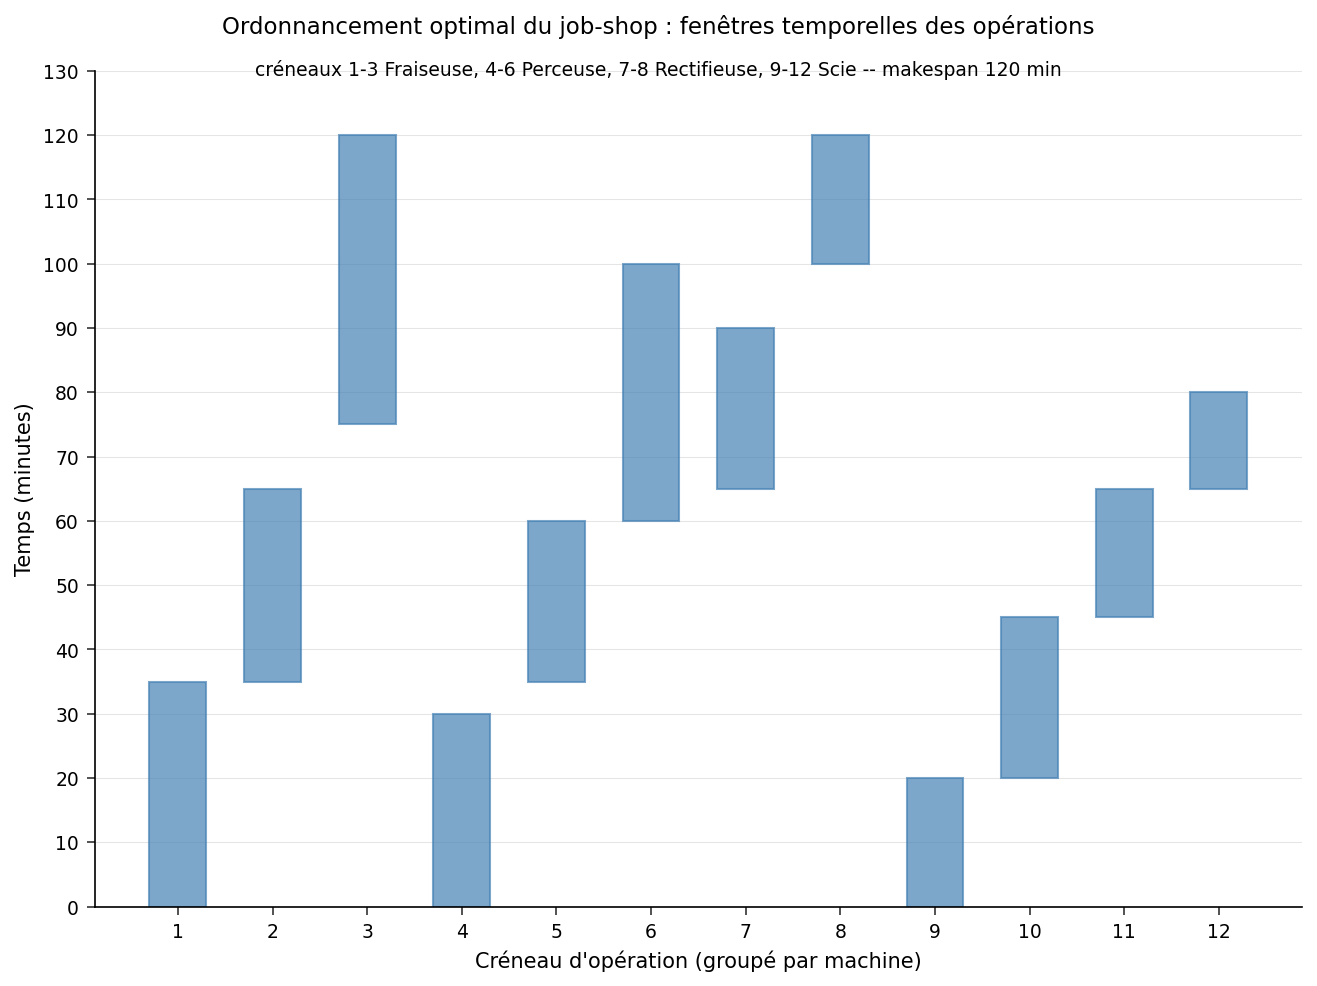

In [4]:
DONNÉES ganttdata;
    DÉFINIR schedule;
    slot + 1;
EXÉCUTER;

PROCÉDURE IMPRIMER DONNÉES=ganttdata noobs ÉTIQUETTE;
    TITRE "Ordonnancement par créneau (l'ordre des créneaux correspond au graphique ci-dessous)";
    VAR slot mname jobname START FINISH;
    ÉTIQUETTE slot="Créneau"
              mname="Machine"
              jobname="Pièce"
              START="Début"
              FINISH="Fin";
EXÉCUTER;

PROCÉDURE SGPLOT DONNÉES=ganttdata noautolegend;
    TITRE "Ordonnancement optimal du job-shop : fenêtres temporelles des opérations";
    title2 "créneaux 1-3 Fraiseuse, 4-6 Perceuse, 7-8 Rectifieuse, 9-12 Scie -- makespan 120 min";
    highlow x=slot HIGH=FINISH LOW=START / type=bar barwidth=0.65
            fillattrs=(color=steel) LINEATTRS=(color=navy);
    XAXIS ÉTIQUETTE="Créneau d'opération (groupé par machine)" integer
          VALUES=(1 JUSQU_À 12 PAR 1);
    YAXIS ÉTIQUETTE="Temps (minutes)" grid VALUES=(0 JUSQU_À 130 PAR 10);
EXÉCUTER;
TITRE;

## Interprétation des résultats

- **Optimalité.** Le solveur MILP a renvoyé `Solution Status = Optimal` avec `Objective Value = 120`, de sorte que **120 minutes est le makespan le plus court possible prouvé** pour cette instance — aucun ordonnancement ne peut se terminer plus tôt. Ce certificat est ce que la formulation en programmation mathématique vous apporte par rapport à une pure recherche de faisabilité.

- **L'ordonnancement respecte chaque contrainte.** À la lecture du tableau par machine, aucune paire d'opérations sur la même machine ne se chevauche (par ex. sur la Scie : Arbre 0–20, Support 20–45, Carter 45–65, Bride 65–80), et chaque pièce s'exécute dans l'ordre technologique (par ex. Carter : Perceuse 0–30, puis Scie 45–65, puis Fraiseuse 75–120). Le graphique à barres flottantes montre la même chose : au sein de la bande de créneaux de chaque machine, les fenêtres temporelles se juxtaposent sans collision.

- **Ce qui fixe la durée de l'ordonnancement.** Deux opérations se terminent exactement à la minute 120 — la Rectifieuse du Support (créneau 8) et la Fraiseuse du Carter (créneau 3). Toutes deux touchent le makespan, de sorte que les machines Rectifieuse et Fraiseuse sont sur le chemin critique ; réduire davantage le makespan exigerait de modifier l'instance elle-même (opérations plus rapides, une machine supplémentaire ou une précédence relâchée), et non simplement de re-séquencer.

- **Comment cela passe à l'échelle.** La formulation croît naturellement : ajoutez une machine comme une autre valeur de `machine`, ajoutez des pièces comme davantage de lignes de `jobshop`, ou modélisez des dates de disponibilité et d'échéance en bornant `s[o]` et en ajoutant des contraintes d'échéance. Autoriser une machine à exécuter plusieurs jobs à la fois (capacité >1) remplace la disjonction par paires par une contrainte de ressource cumulative. Le même MILP OPTMODEL gère alors des règles d'atelier plus riches sans changer de solveur.